# Statistical associations with eddy tilt direction

This notebook asks which surface and environmental feature groups have stable associations with **circular tilt direction**, independently for AE and CE. Direction is analysed only for tilt magnitude ≥5 km.

For scalability, two clustered GEE models estimate the eastward and northward components of the unit tilt vector. Their predictions are recombined into direction and resultant concentration. This respects angular wrap-around and repeated eddy-days, but it is not a fully joint projected-normal likelihood; the strongest findings can later be confirmed with a formal circular mixed model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
import patsy

import seacofs_tilt_tools as tilt
import ml_subsurface_tools as ml

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.dpi"] = 120
GRID_ROTATION_DEG = 20.0
DIRECTION_MIN_TILT_KM = 5.0
RUN_THRESHOLD_SENSITIVITY = False
print("statsmodels", statsmodels.__version__, "patsy", patsy.__version__)

statsmodels 0.14.6 patsy 1.0.2


## 1. Predeclared hypotheses

- CE direction is biased toward the raw PV-gradient bearing; AE is biased toward the opposite bearing, but neither is expected to be perfectly aligned.
- PV unit direction components contribute beyond PV magnitude.
- Propagation may encode EAC pathway rather than a direct daily dynamical association; within-eddy and between-eddy effects must therefore be distinguished.
- Ellipse orientation may contribute through its doubled-angle geographic encoding.
- Beta, `Rc`, `Omega`, and bathymetry may shift the directional distribution through nonlinear associations.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
df_vert = tilt.load_vert(paths)
max_depth = (df_vert.groupby(["Eddy", "Day"], as_index=False)["Depth"]
             .max().rename(columns={"Depth": "max_profile_depth"}))
df_eddies = df_eddies.merge(max_depth, on=["Eddy", "Day"], how="inner")
df_eddies = df_eddies[df_eddies["max_profile_depth"] > 850].copy()
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

# only condier planetary eddies
df_eddies = df_eddies[df_eddies.topo_plan_ratio<0].copy()

model_df = ml.prepare_modelling_table(df_eddies, grid_rotation_deg=GRID_ROTATION_DEG)
model_df = model_df[model_df["TiltDis"] >= DIRECTION_MIN_TILT_KM].copy()
polarity_data = {cyc: model_df[model_df["Cyc"] == cyc].copy() for cyc in ("AE", "CE")}
display(pd.DataFrame({cyc: {"rows": len(x), "eddies": x.Eddy.nunique()}
                      for cyc, x in polarity_data.items()}).T)

,rows,eddies
AE,10907,688
CE,3771,527


## 2. Direct circular description relative to PV

The expected reference is raw PV for CE and PV+180° for AE. Circular mean offset indicates systematic rotation from that reference; resultant length ranges from 0 (dispersed) to 1 (concentrated). Eddy-level summaries prevent long tracks dominating.

AE


,mean_delta_PV_deg,PV_alignment_concentration
count,688.000,688.000
mean,6.943,0.737
std,86.071,0.267
min,-179.093,0.045
25%,-50.200,0.558
50%,9.650,0.835
75%,68.509,0.977
max,179.327,1.000


CE


,mean_delta_PV_deg,PV_alignment_concentration
count,527.000,527.000
mean,-25.840,0.840
std,78.243,0.207
min,-175.027,0.106
25%,-77.513,0.753
50%,-38.636,0.936
75%,13.133,0.995
max,179.421,1.000


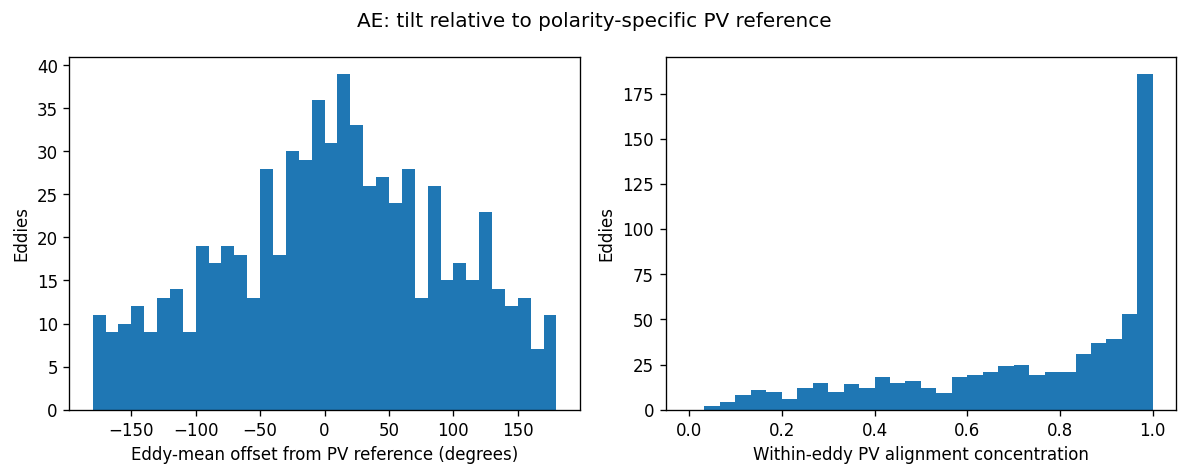

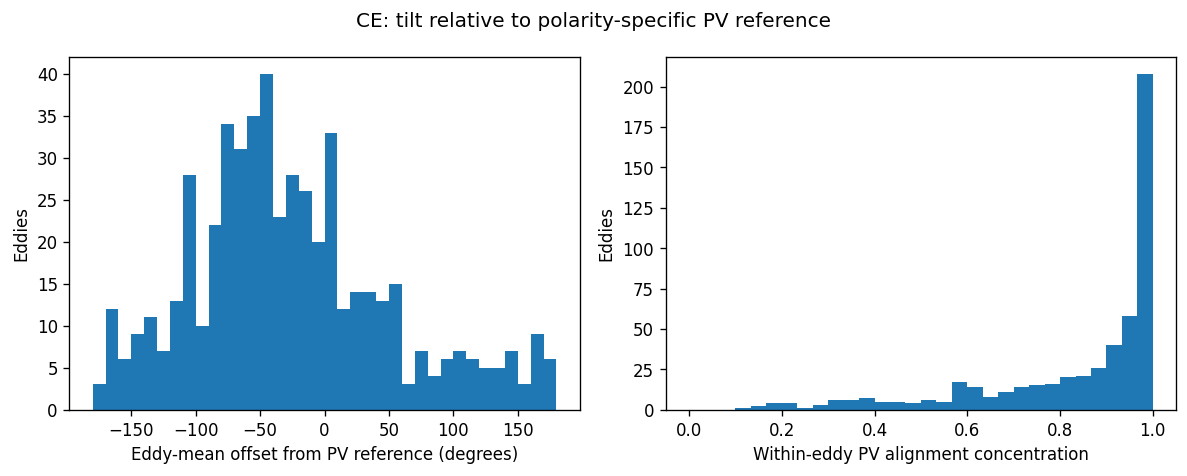

In [3]:
pv_relative = {}
for cyc, part in polarity_data.items():
    summary = ml.pv_relative_direction_summary(part)
    pv_relative[cyc] = summary
    print(cyc)
    display(summary[["mean_delta_PV_deg", "PV_alignment_concentration"]].describe().round(3))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(summary["mean_delta_PV_deg"], bins=np.arange(-180, 185, 10))
    axes[0].set(xlabel="Eddy-mean offset from PV reference (degrees)", ylabel="Eddies")
    axes[1].hist(summary["PV_alignment_concentration"], bins=np.linspace(0, 1, 31))
    axes[1].set(xlabel="Within-eddy PV alignment concentration", ylabel="Eddies")
    fig.suptitle(f"{cyc}: tilt relative to polarity-specific PV reference")
    fig.tight_layout()

## 3. Within-eddy and between-eddy directional predictors

Between terms compare characteristic eddy pathways/structures. Within terms test whether a daily change within the same eddy accompanies a directional change. PV and ellipse directions remain in their circular component encodings.

In [4]:
association_data = {}
association_scaling = {}
for cyc, part in polarity_data.items():
    association_data[cyc], association_scaling[cyc] = ml.prepare_association_table(part)

## 4. Clustered circular-component association models

Separate east/north GEE fits use identical nonlinear terms and cluster-robust eddy uncertainty. The joint table reports whether a feature group is associated with either component; practical importance must also be checked through direction/concentration curves and the nested predictive ablation.

In [5]:
direction_gee = {}
direction_fit_data = {}
for cyc in ("AE", "CE"):
    print(f"Fitting {cyc} direction GEE pair...")
    results, common_index = ml.fit_direction_gee(association_data[cyc], covariance="exchangeable")
    direction_gee[cyc] = results
    direction_fit_data[cyc] = association_data[cyc].loc[common_index].copy()
    display(ml.direction_group_wald_table(results).round(4))

Fitting AE direction GEE pair...


,east_parameters_tested,east_wald_statistic,east_p_value,north_parameters_tested,north_wald_statistic,north_p_value
group,,,,,,
PV,12,38.1585,0.0001,12,30.3128,0.0025
beta,10,17.8683,0.0572,10,74.1221,0.0000
ellipse,2,91.6219,0.0000,2,26.8022,0.0000
environment,22,355.7049,0.0000,22,97.5677,0.0000
propagation,4,297.3774,0.0000,4,263.4832,0.0000
structure,22,155.7105,0.0000,22,77.5921,0.0000


Fitting CE direction GEE pair...


,east_parameters_tested,east_wald_statistic,east_p_value,north_parameters_tested,north_wald_statistic,north_p_value
group,,,,,,
PV,12,20.2787,0.0620,12,62.0792,0.0000
beta,10,19.7817,0.0314,10,29.4368,0.0011
ellipse,2,15.4099,0.0005,2,9.4376,0.0089
environment,22,197.5281,0.0000,22,110.0742,0.0000
propagation,4,101.1857,0.0000,4,99.1431,0.0000
structure,22,100.2974,0.0000,22,69.9360,0.0000


## 5. Direction and concentration effect curves

Direction shows how the conditional mean bearing changes. Concentration shows how strongly the component predictions define a preferred direction; a direction curve is not scientifically meaningful where concentration is close to zero.

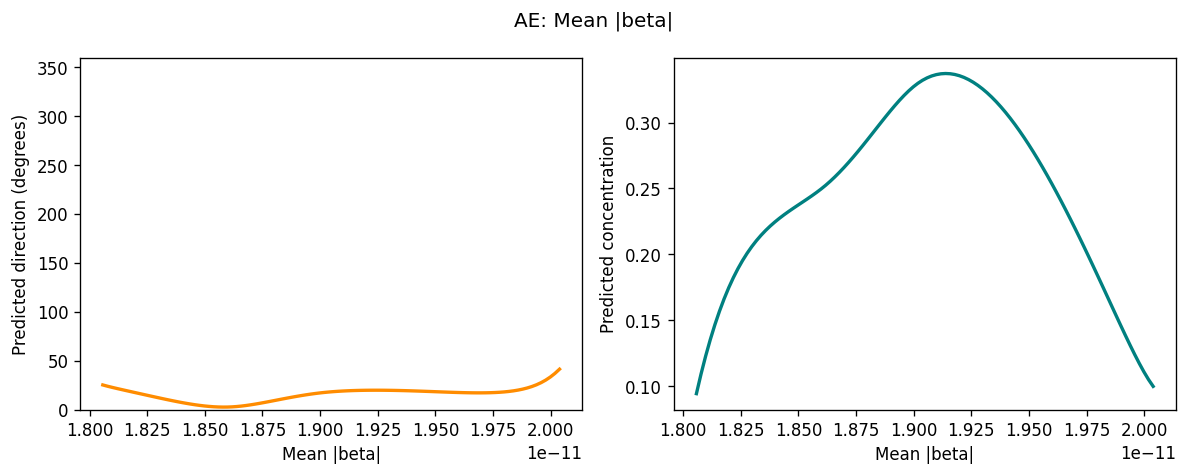

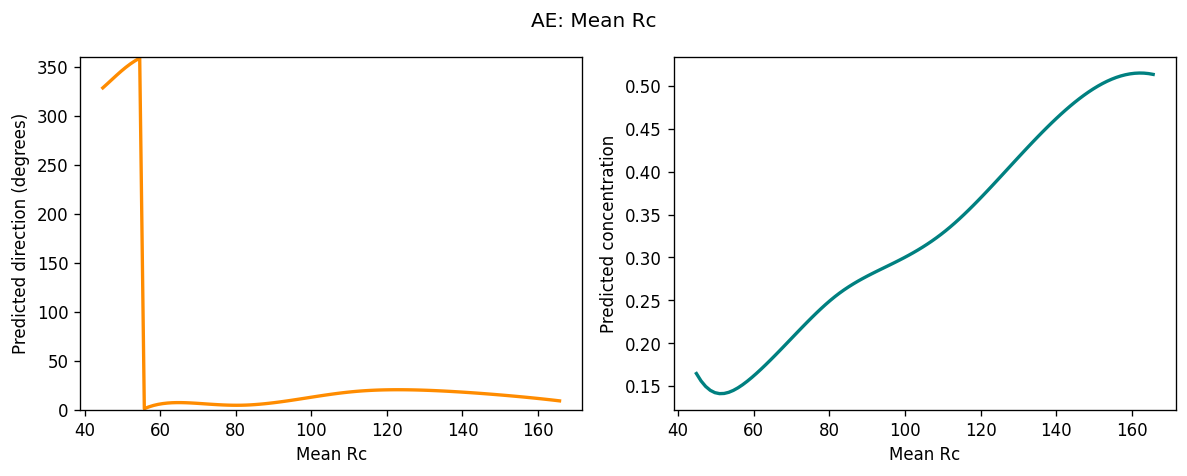

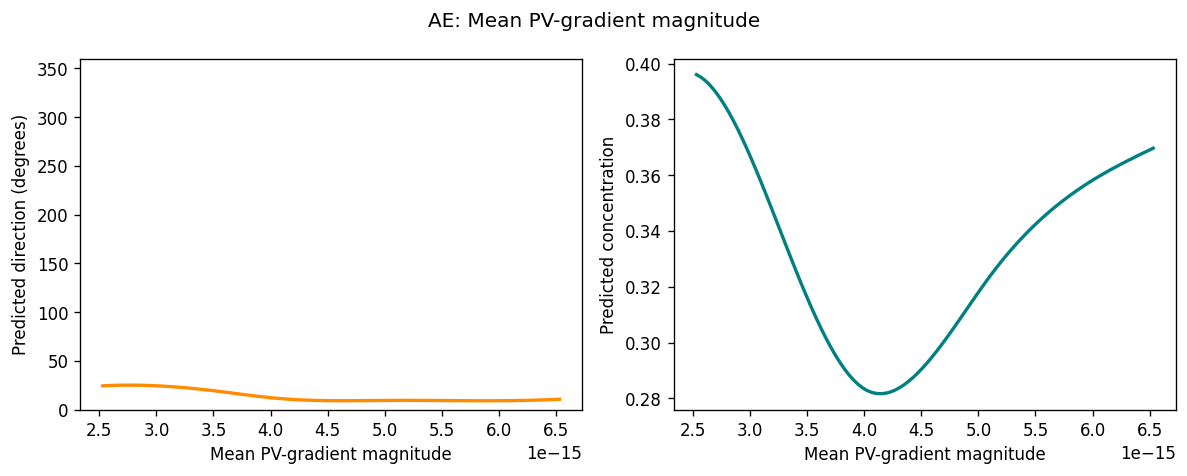

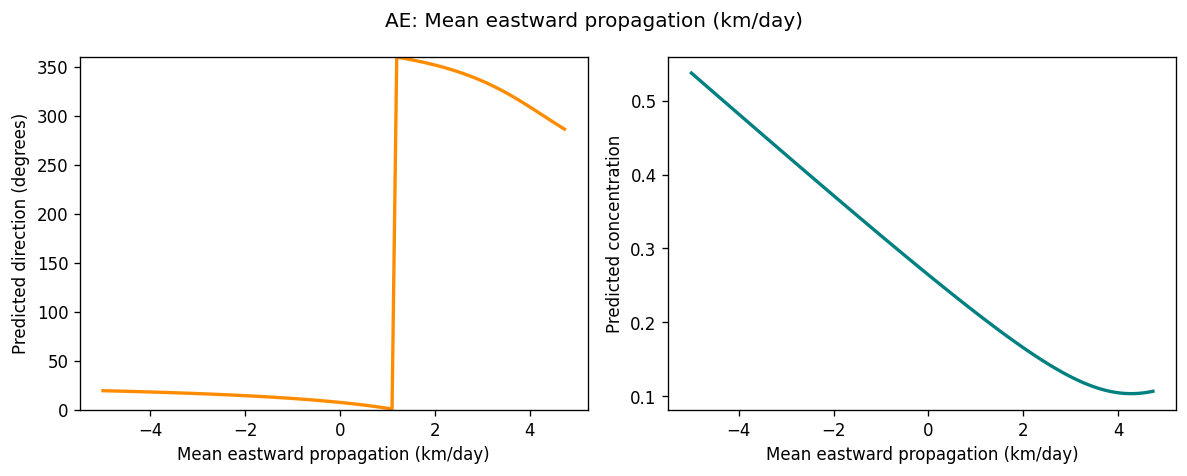

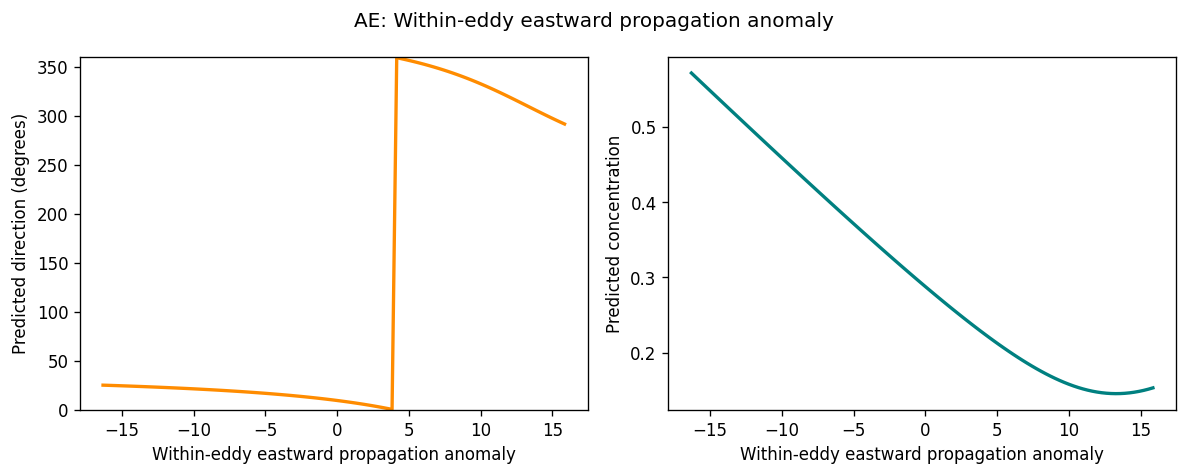

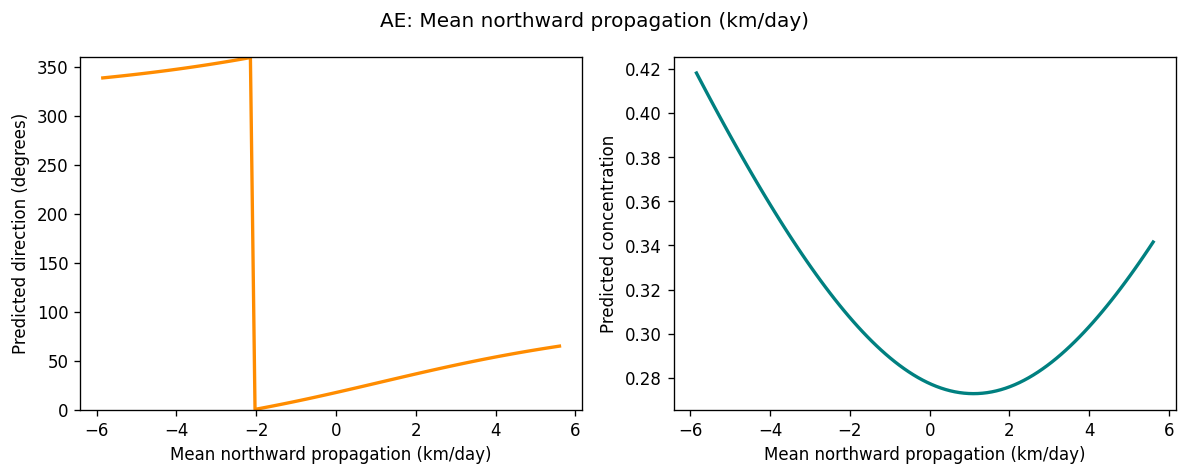

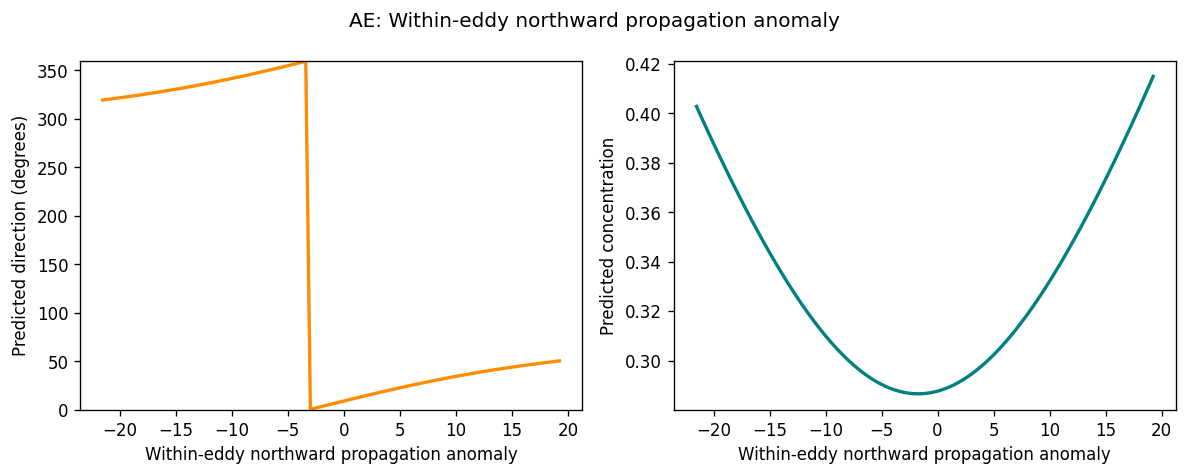

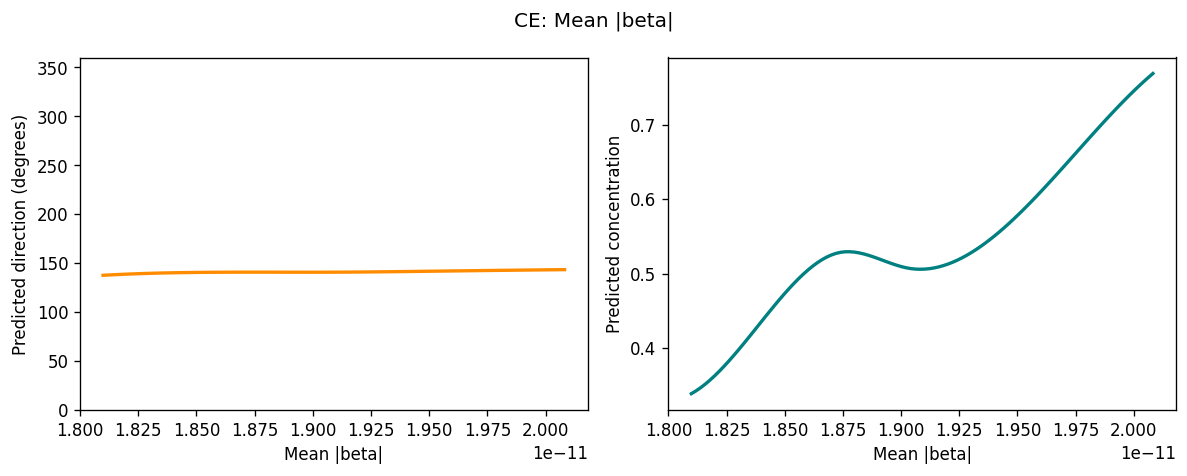

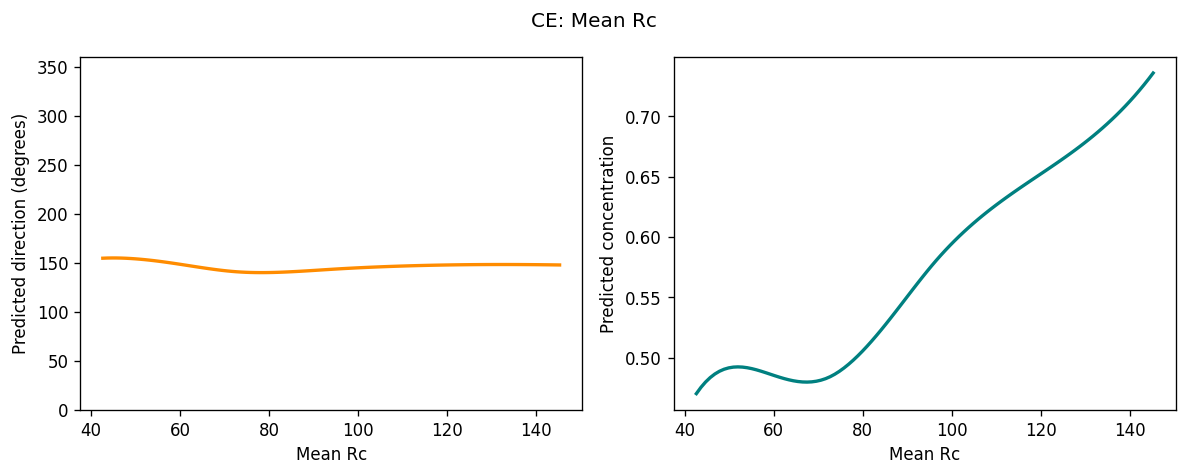

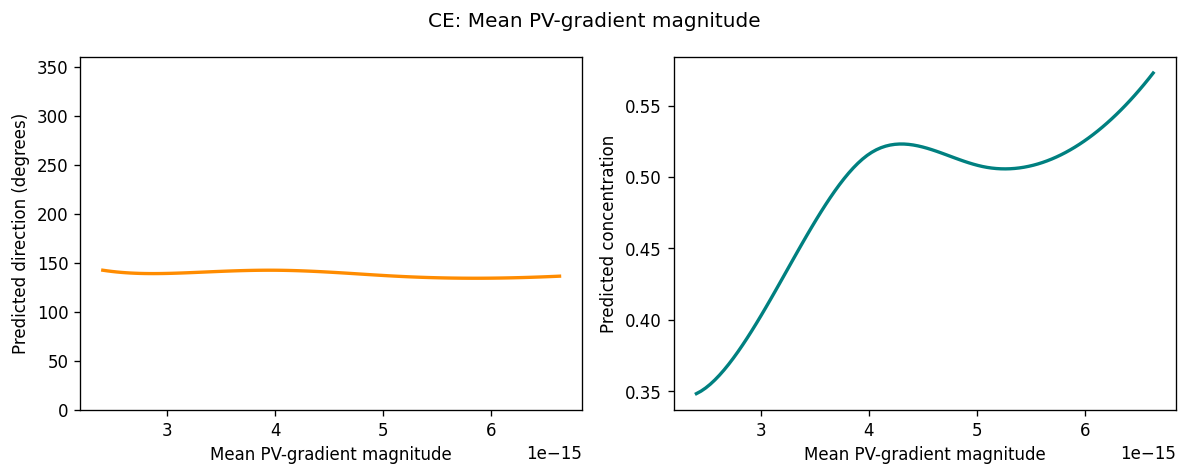

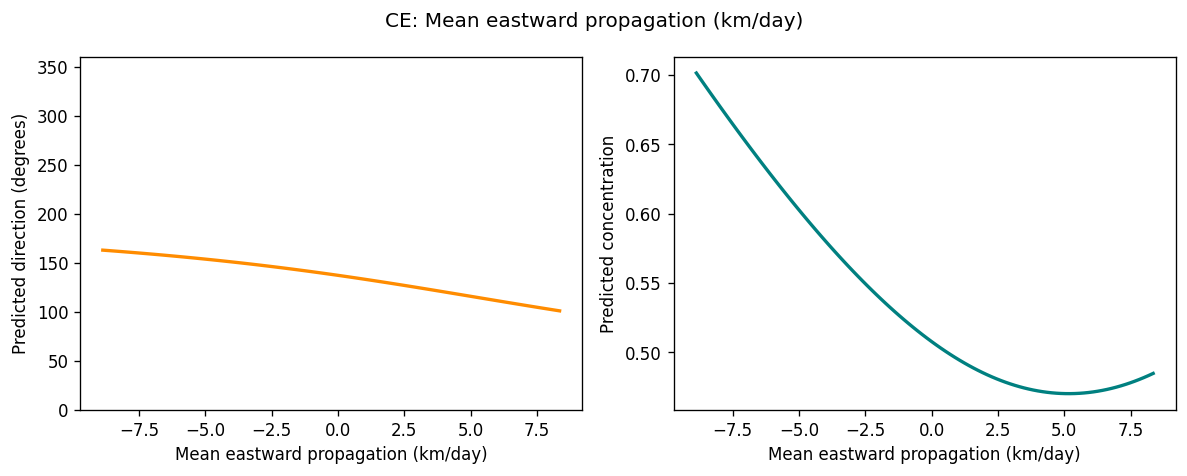

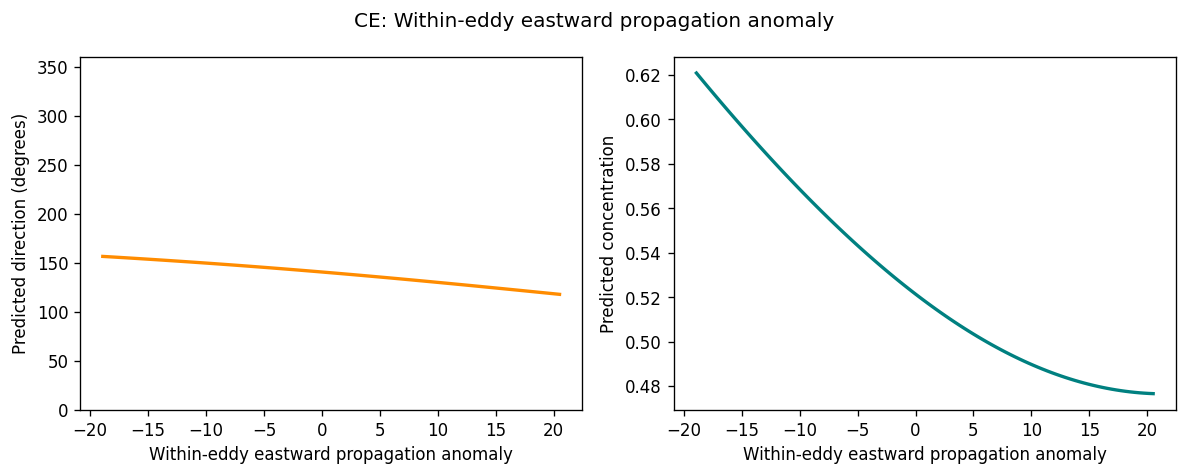

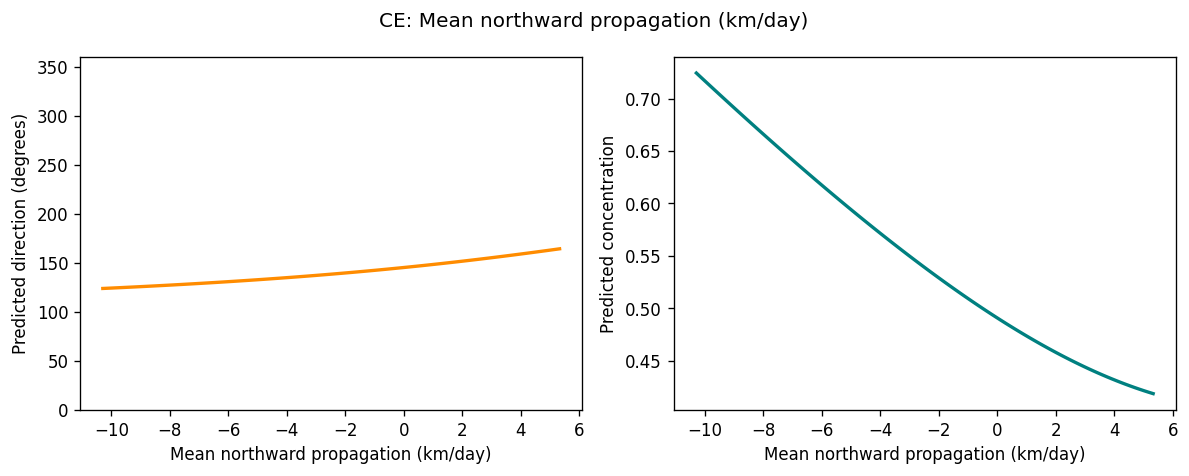

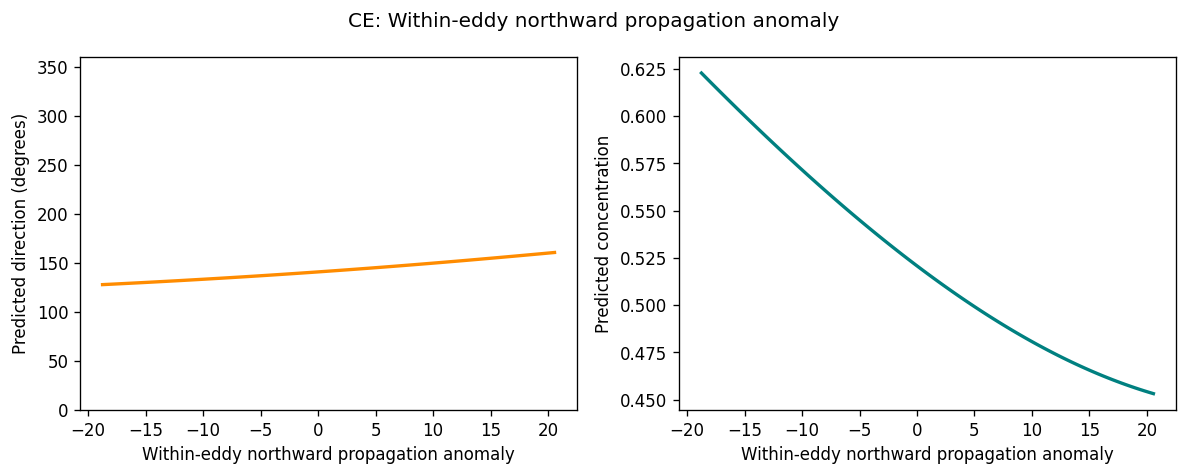

In [6]:
direction_curves = {}
curve_features = {
    "abs_beta_between_z": "Mean |beta|",
    "Rc_between_z": "Mean Rc",
    "PV_grad_mag_between_z": "Mean PV-gradient magnitude",
    "prop_east_km_day_between_z": "Mean eastward propagation (km/day)",
    "prop_east_km_day_within_z": "Within-eddy eastward propagation anomaly",
    "prop_north_km_day_between_z": "Mean northward propagation (km/day)",
    "prop_north_km_day_within_z": "Within-eddy northward propagation anomaly",
}
for cyc in ("AE", "CE"):
    direction_curves[cyc] = {}
    for feature, label in curve_features.items():
        curve = ml.direction_effect_curve(
            direction_gee[cyc], direction_fit_data[cyc], feature,
            scaling=association_scaling[cyc],
        )
        direction_curves[cyc][feature] = curve
        ml.plot_direction_effect_curve(curve, xlabel=label, title=f"{cyc}: {label}")

## 6. PV and ellipse directional terms

PV unit and ellipse doubled-angle components cannot be interpreted through a one-dimensional component curve. Inspect their joint robust tests and compare fitted versus observed relative-angle distributions. The ML `full` versus `without_PV` and `without_ellipse` results provide the corresponding out-of-sample effect-size evidence.

In [7]:
component_terms = ["PV_grad_unit_east", "PV_grad_unit_north",
                   "ellipse_major_cos2", "ellipse_major_sin2"]
for cyc, results in direction_gee.items():
    rows = []
    for component, result in results.items():
        table = pd.DataFrame({"coefficient": result.params, "SE": result.bse, "p_value": result.pvalues})
        table = table.loc[table.index.intersection(component_terms)].assign(response_component=component)
        rows.append(table)
    print(cyc)
    display(pd.concat(rows).round(4))

AE


,coefficient,SE,p_value,response_component
ellipse_major_cos2,-0.1961,0.0207,0.0000,east
ellipse_major_sin2,-0.0534,0.0207,0.0099,east
PV_grad_unit_east,0.1103,0.0343,0.0013,east
PV_grad_unit_north,-0.1640,0.0892,0.0660,east
ellipse_major_cos2,0.0474,0.0192,0.0135,north
ellipse_major_sin2,-0.0903,0.0194,0.0000,north
PV_grad_unit_east,-0.0005,0.0339,0.9888,north
PV_grad_unit_north,0.2875,0.0868,0.0009,north


CE


,coefficient,SE,p_value,response_component
ellipse_major_cos2,0.1256,0.0321,0.0001,east
ellipse_major_sin2,0.0039,0.0300,0.8978,east
PV_grad_unit_east,0.0798,0.0376,0.0338,east
PV_grad_unit_north,0.0813,0.0898,0.3653,east
ellipse_major_cos2,0.0035,0.0244,0.8850,north
ellipse_major_sin2,0.0732,0.0244,0.0027,north
PV_grad_unit_east,0.0311,0.0328,0.3440,north
PV_grad_unit_north,0.1378,0.0848,0.1041,north


## 7. Threshold and covariance sensitivity

Working-independence fits are run by default. Setting `RUN_THRESHOLD_SENSITIVITY=True` additionally refits the models above 10 and 20 km. Stable directional associations should retain compatible group conclusions as direction becomes better defined.

In [8]:
for cyc in ("AE", "CE"):
    independent, _ = ml.fit_direction_gee(association_data[cyc], covariance="independence")
    print(cyc, "working-independence sensitivity")
    display(ml.direction_group_wald_table(independent).round(4))

if RUN_THRESHOLD_SENSITIVITY:
    for threshold in (10.0, 20.0):
        for cyc, original in polarity_data.items():
            subset = original[original["TiltDis"] >= threshold].copy()
            prepared, _ = ml.prepare_association_table(subset)
            results, _ = ml.fit_direction_gee(prepared, covariance="exchangeable")
            print(cyc, f"TiltDis >= {threshold:g} km")
            display(ml.direction_group_wald_table(results).round(4))

AE working-independence sensitivity


,east_parameters_tested,east_wald_statistic,east_p_value,north_parameters_tested,north_wald_statistic,north_p_value
group,,,,,,
PV,12,35.2866,0.0004,12,27.6692,0.0062
beta,10,20.4268,0.0255,10,54.3270,0.0000
ellipse,2,81.5293,0.0000,2,29.1236,0.0000
environment,22,412.8606,0.0000,22,103.9154,0.0000
propagation,4,333.9130,0.0000,4,346.9078,0.0000
structure,22,180.4283,0.0000,22,82.7988,0.0000


CE working-independence sensitivity


,east_parameters_tested,east_wald_statistic,east_p_value,north_parameters_tested,north_wald_statistic,north_p_value
group,,,,,,
PV,12,27.0195,0.0077,12,67.6668,0.0000
beta,10,19.7027,0.0322,10,36.1973,0.0001
ellipse,2,14.7419,0.0006,2,5.0773,0.0790
environment,22,204.7304,0.0000,22,129.4803,0.0000
propagation,4,118.6601,0.0000,4,109.8757,0.0000
structure,22,95.3128,0.0000,22,49.5146,0.0007


## 8. Reporting template

For AE and CE separately report: (1) the eddy-level PV-relative offset and concentration distribution; (2) joint east/north feature-group tests; (3) between-eddy versus within-eddy propagation curves; (4) curve concentration wherever direction is interpreted; (5) compatibility under working-independence and magnitude-threshold sensitivity; and (6) nested-ML angular-error change after removing the same group.

A poor propagation-direction baseline does not prove propagation is irrelevant: components can still encode pathway or interact with other covariates. A group should be called stably associated only when statistical, predictive, threshold, and spatial evidence agree.